# Notebook 01 — Dataset Exploration

**PharmaLens: An Explainable AI Framework for Drug–Target Interaction Prediction**

---

## Objective

This notebook performs an initial exploration of the **KIBA** (Kinase Inhibitor BioActivity) benchmark dataset for Drug–Target Interaction (DTI) prediction.

We will:
1. Download and load the raw KIBA dataset
2. Inspect the data format and structure
3. Compute basic statistics (records, unique drugs, unique targets)
4. Analyze missing values and duplicates
5. Visualize interaction score distributions
6. Visualize drug and protein distributions
7. Generate a comprehensive dataset summary

**Why this matters:** Before building any model, we must understand the data — its size, shape, distributions, and potential issues. This ensures that preprocessing and modeling decisions are data-driven.

## Setup

In [3]:
# Standard imports
import os
import sys
import json
import pickle
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Add project root to path
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

# PharmaLens modules
from src.utils.config import (
    RAW_DATA_DIR, PROCESSED_DATA_DIR, METADATA_DIR,
    FIGURES_DIR, ensure_dirs, set_seed, set_plot_style, save_json
)
from src.data.download import (
    download_dataset, load_raw_dataset, create_interaction_dataframe,
    generate_dataset_summary, print_dataset_summary
)

# Setup
set_seed(42)
COLORS = set_plot_style()
ensure_dirs()

print(f"Project root: {PROJECT_ROOT}")
print(f"NumPy: {np.__version__}")
print(f"Pandas: {pd.__version__}")
print("Setup complete ✓")

Project root: C:\Users\ASUS\Documents\projects\Pharmalens
NumPy: 2.5.2
Pandas: 3.0.5
Setup complete ✓


## 1. Dataset Download

The KIBA dataset is downloaded from the [DeepDTA repository](https://github.com/hkmztrk/DeepDTA).

**KIBA** (Kinase Inhibitor BioActivity) integrates bioactivity data from multiple sources (Ki, Kd, IC50) into a unified KIBA score. It is a widely-used benchmark for DTI prediction.

The raw data consists of:
- `ligands_can.txt` — Drug SMILES strings (text representation of chemical molecules)
- `proteins.txt` — Protein amino acid sequences
- `Y` — Interaction score matrix (drugs × targets)

In [4]:
# Download KIBA dataset (skips if already downloaded)
success = download_dataset("kiba")
print(f"\nDownload successful: {success}")

# List downloaded files
kiba_dir = RAW_DATA_DIR / "kiba"
print(f"\nFiles in {kiba_dir}:")
for f in sorted(kiba_dir.iterdir()):
    size_kb = f.stat().st_size / 1024
    print(f"  {f.name:<25s} {size_kb:>10.1f} KB")

2026-09-11 21:35:40 | pharmalens.data | INFO | Downloading kiba/ligands_can.txt from https://raw.githubusercontent.com/hkmztrk/DeepDTA/master/data/kiba/ligands_can.txt
kiba/ligands_can.txt: 166kB [00:00, 5.64MB/s]                    
2026-09-11 21:35:41 | pharmalens.data | INFO | Downloaded: ligands_can.txt (165,908 bytes)
2026-09-11 21:35:41 | pharmalens.data | INFO | Downloading kiba/proteins.txt from https://raw.githubusercontent.com/hkmztrk/DeepDTA/master/data/kiba/proteins.txt
kiba/proteins.txt: 170kB [00:00, 2.84MB/s]                    
2026-09-11 21:35:42 | pharmalens.data | INFO | Downloaded: proteins.txt (170,137 bytes)
2026-09-11 21:35:42 | pharmalens.data | INFO | Downloading kiba/Y from https://raw.githubusercontent.com/hkmztrk/DeepDTA/master/data/kiba/Y
kiba/Y: 100%|██████████| 3.87M/3.87M [00:00<00:00, 9.20MB/s]
2026-09-11 21:35:45 | pharmalens.data | INFO | Downloaded: Y (3,867,510 bytes)
2026-09-11 21:35:45 | pharmalens.data | INFO | ✓ Dataset 'kiba' downloaded success


Download successful: True

Files in C:\Users\ASUS\Documents\projects\Pharmalens\data\raw\kiba:
  ligands_can.txt                162.0 KB
  proteins.txt                   166.1 KB
  Y                             3776.9 KB


## 2. Load Raw Data

We load the three components:
- **Ligands (drugs):** A dictionary mapping drug IDs to SMILES strings
- **Proteins (targets):** A dictionary mapping target IDs to amino acid sequences
- **Interaction matrix (Y):** A 2D matrix where Y[i,j] is the KIBA score for drug i and target j. NaN values indicate unmeasured interactions.

In [5]:
# Load all components
ligands, proteins, Y = load_raw_dataset("kiba")

print(f"Number of drugs (ligands): {len(ligands)}")
print(f"Number of proteins (targets): {len(proteins)}")
print(f"Interaction matrix shape: {Y.shape}")
print(f"Interaction matrix dtype: {Y.dtype}")

2026-09-11 21:35:51 | pharmalens.data | INFO | Loaded 2111 drugs from kiba
2026-09-11 21:35:51 | pharmalens.data | INFO | Loaded 229 proteins from kiba
2026-09-11 21:35:51 | pharmalens.data | INFO | Loaded interaction matrix: shape=(2111, 229) from kiba


Number of drugs (ligands): 2111
Number of proteins (targets): 229
Interaction matrix shape: (2111, 229)
Interaction matrix dtype: float64


In [6]:
# Peek at a few drugs
drug_ids = list(ligands.keys())[:5]
print("Sample drugs (SMILES):")
for did in drug_ids:
    print(f"  {did}: {ligands[did][:80]}{'...' if len(ligands[did]) > 80 else ''}")

print()

# Peek at a few proteins
target_ids = list(proteins.keys())[:3]
print("Sample proteins (sequences):")
for tid in target_ids:
    seq = proteins[tid]
    print(f"  {tid}: {seq[:60]}... (length={len(seq)})")

Sample drugs (SMILES):
  CHEMBL1087421: COC1=C(C=C2C(=C1)CCN=C2C3=CC(=C(C=C3)Cl)Cl)Cl
  CHEMBL1088633: COC1=C(C=C2C(=C1)CCN=C2C3=CC(=CC=C3)Cl)Cl
  CHEMBL1090360: C1COCCN1C2=CC(=CC=C2)NC3=NC=CC(=N3)C4=C(N=C5N4C=CS5)C6=CC(=CC=C6)NC(=O)CC7=CC=CC...
  CHEMBL1688215: C1=CC2=C(C=C1C3=NC(=NC=C3)N)NN=C2N
  CHEMBL1765781: CNC1=NC(=CN=C1)C2=CNC(=O)C(=C2)NC(=O)C3=CC=C(C=C3)N4CCCC4CN5CCCC5

Sample proteins (sequences):
  O00141: MTVKTEAAKGTLTYSRMRGMVAILIAFMKQRRMGLNDFIQKIANNSYACKHPEVQSILKI... (length=431)
  O00311: MEASLGIQMDEPMAFSPQRDRFQAEGSLKKNEQNFKLAGVKKDIEKLYEAVPQLSNVFKI... (length=574)
  O00329: MPPGVDCPMEFWTKEENQSVVVDFLLPTGVYLNFPVSRNANLSTIKQLLWHRAQYEPLFH... (length=1044)


## 3. Create Interaction DataFrame

We convert the interaction matrix into a tidy DataFrame where each row represents one measured drug–target interaction:

| drug_id | target_id | smiles | sequence | score |
|---------|-----------|--------|----------|-------|

Only measured interactions (non-NaN values) are included.

In [7]:
# Create DataFrame from raw data
df = create_interaction_dataframe(ligands, proteins, Y, "kiba")

print(f"DataFrame shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print()
df.head(10)

2026-09-11 21:35:58 | pharmalens.data | INFO | Created interaction DataFrame: 118,254 rows, 2111 drugs, 229 targets


DataFrame shape: (118254, 5)
Columns: ['drug_id', 'target_id', 'smiles', 'sequence', 'score']



,drug_id,target_id,smiles,sequence,score
0,CHEMBL1087421,O00141,COC1=C(C=C2C(=C1)CCN=C2C3=CC(=C(C=C3)Cl)Cl)Cl,MTVKTEAAKGTLTYSRMRGMVAILIAFMKQRRMGLNDFIQKIANNS...,11.1
1,CHEMBL1087421,O14920,COC1=C(C=C2C(=C1)CCN=C2C3=CC(=C(C=C3)Cl)Cl)Cl,MSWSPSLTTQTCGAWEMKERLGTGGFGNVIRWHNQETGEQIAIKQC...,11.1
2,CHEMBL1087421,O15111,COC1=C(C=C2C(=C1)CCN=C2C3=CC(=C(C=C3)Cl)Cl)Cl,MERPPGLRPGAGGPWEMRERLGTGGFGNVCLYQHRELDLKIAIKSC...,11.1
3,CHEMBL1087421,P00533,COC1=C(C=C2C(=C1)CCN=C2C3=CC(=C(C=C3)Cl)Cl)Cl,MRPSGTAGAALLALLAALCPASRALEEKKVCQGTSNKLTQLGTFED...,11.1
4,CHEMBL1087421,P04626,COC1=C(C=C2C(=C1)CCN=C2C3=CC(=C(C=C3)Cl)Cl)Cl,MELAALCRWGLLLALLPPGAASTQVCTGTDMKLRLPASPETHLDML...,11.1
5,CHEMBL1087421,P06239,COC1=C(C=C2C(=C1)CCN=C2C3=CC(=C(C=C3)Cl)Cl)Cl,MGCGCSSHPEDDWMENIDVCENCHYPIVPLDGKGTLLIRNGSEVRD...,11.1
6,CHEMBL1087421,P07333,COC1=C(C=C2C(=C1)CCN=C2C3=CC(=C(C=C3)Cl)Cl)Cl,MGPGVLLLLLVATAWHGQGIPVIEPSVPELVVKPGATVTLRCVGNG...,11.1
7,CHEMBL1087421,P15056,COC1=C(C=C2C(=C1)CCN=C2C3=CC(=C(C=C3)Cl)Cl)Cl,MAALSGGGGGGAEPGQALFNGDMEPEAGAGAGAAASSAADPAIPEE...,11.1
8,CHEMBL1087421,P24941,COC1=C(C=C2C(=C1)CCN=C2C3=CC(=C(C=C3)Cl)Cl)Cl,MENFQKVEKIGEGTYGVVYKARNKLTGEVVALKKIRLDTETEGVPS...,11.1
9,CHEMBL1087421,P28482,COC1=C(C=C2C(=C1)CCN=C2C3=CC(=C(C=C3)Cl)Cl)Cl,MAAAAAAGAGPEMVRGQVFDVGPRYTNLSYIGEGAYGMVCSAYDNV...,10.1


## 4. Basic Statistics

In [8]:
# Core statistics
print("=" * 55)
print("  KIBA DATASET — BASIC STATISTICS")
print("=" * 55)
print(f"  Total interaction records:     {len(df):>10,}")
print(f"  Unique drugs:                  {df['drug_id'].nunique():>10,}")
print(f"  Unique protein targets:        {df['target_id'].nunique():>10,}")
print(f"  Interaction matrix shape:      {str(Y.shape):>10s}")
print(f"  Total matrix entries:          {Y.size:>10,}")
print(f"  Measured (non-NaN):            {np.sum(~np.isnan(Y)):>10,}")
print(f"  Unmeasured (NaN):              {np.sum(np.isnan(Y)):>10,}")
print(f"  Matrix sparsity:               {np.sum(np.isnan(Y)) / Y.size * 100:>9.1f}%")
print("=" * 55)

  KIBA DATASET — BASIC STATISTICS
  Total interaction records:        118,254
  Unique drugs:                       2,111
  Unique protein targets:               229
  Interaction matrix shape:      (2111, 229)
  Total matrix entries:             483,419
  Measured (non-NaN):               118,254
  Unmeasured (NaN):                 365,165
  Matrix sparsity:                    75.5%


In [10]:
# Data types and memory usage
print("\nColumn data types:")
print(df.dtypes)
print(f"\nMemory usage: {df.memory_usage(deep=True).sum() / 1024 / 1024:.1f} MB")


Column data types:
drug_id          str
target_id        str
smiles           str
sequence         str
score        float64
dtype: object

Memory usage: 113.7 MB


## 5. Missing Values

Missing Values Summary:
   Column  Missing Count  Missing %
  drug_id              0        0.0
target_id              0        0.0
   smiles              0        0.0
 sequence              0        0.0
    score              0        0.0


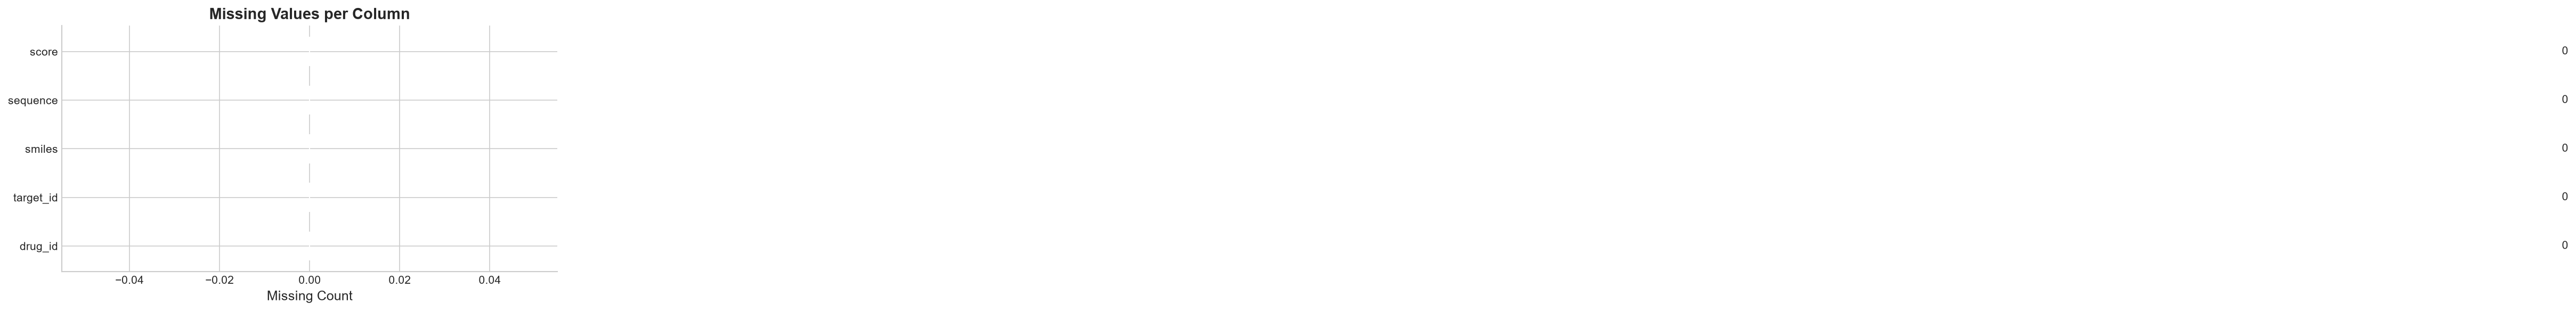


Plot saved: C:\Users\ASUS\Documents\projects\Pharmalens\results\figures\missing_values.png


In [11]:
# Check missing values in the DataFrame
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Column': missing.index,
    'Missing Count': missing.values,
    'Missing %': missing_pct.values
})

print("Missing Values Summary:")
print(missing_df.to_string(index=False))

# Visualize
fig, ax = plt.subplots(figsize=(8, 4))
colors = [COLORS['success'] if v == 0 else COLORS['error'] for v in missing.values]
bars = ax.barh(missing.index, missing.values, color=colors, edgecolor='white', height=0.6)
ax.set_xlabel('Missing Count')
ax.set_title('Missing Values per Column', fontweight='bold')

for bar, val in zip(bars, missing.values):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'missing_values.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"\nPlot saved: {FIGURES_DIR / 'missing_values.png'}")

## 6. Duplicate Records

In [12]:
# Check for duplicate (drug_id, target_id) pairs
n_duplicate_pairs = df.duplicated(subset=['drug_id', 'target_id']).sum()
n_duplicate_rows = df.duplicated().sum()

print(f"Duplicate (drug_id, target_id) pairs: {n_duplicate_pairs}")
print(f"Fully duplicate rows: {n_duplicate_rows}")

if n_duplicate_pairs > 0:
    print("\nSample duplicates:")
    dupes = df[df.duplicated(subset=['drug_id', 'target_id'], keep=False)]
    print(dupes.head(10))

Duplicate (drug_id, target_id) pairs: 0
Fully duplicate rows: 0


## 7. Interaction Score Distribution

The KIBA score represents drug–target binding affinity:
- **Low KIBA score** → Strong binding (the drug interacts strongly with the protein)
- **High KIBA score** → Weak binding (little or no interaction)

Understanding this distribution helps us choose appropriate modeling and evaluation strategies.

In [13]:
# Score statistics
print("Interaction Score (KIBA) Statistics:")
print(df['score'].describe().round(4))
print(f"\nSkewness: {df['score'].skew():.4f}")
print(f"Kurtosis: {df['score'].kurtosis():.4f}")

Interaction Score (KIBA) Statistics:
count    118254.0000
mean         11.7199
std           0.8369
min           0.0000
25%          11.2000
50%          11.5000
75%          11.9239
max          17.2002
Name: score, dtype: float64

Skewness: 1.1646
Kurtosis: 4.5088


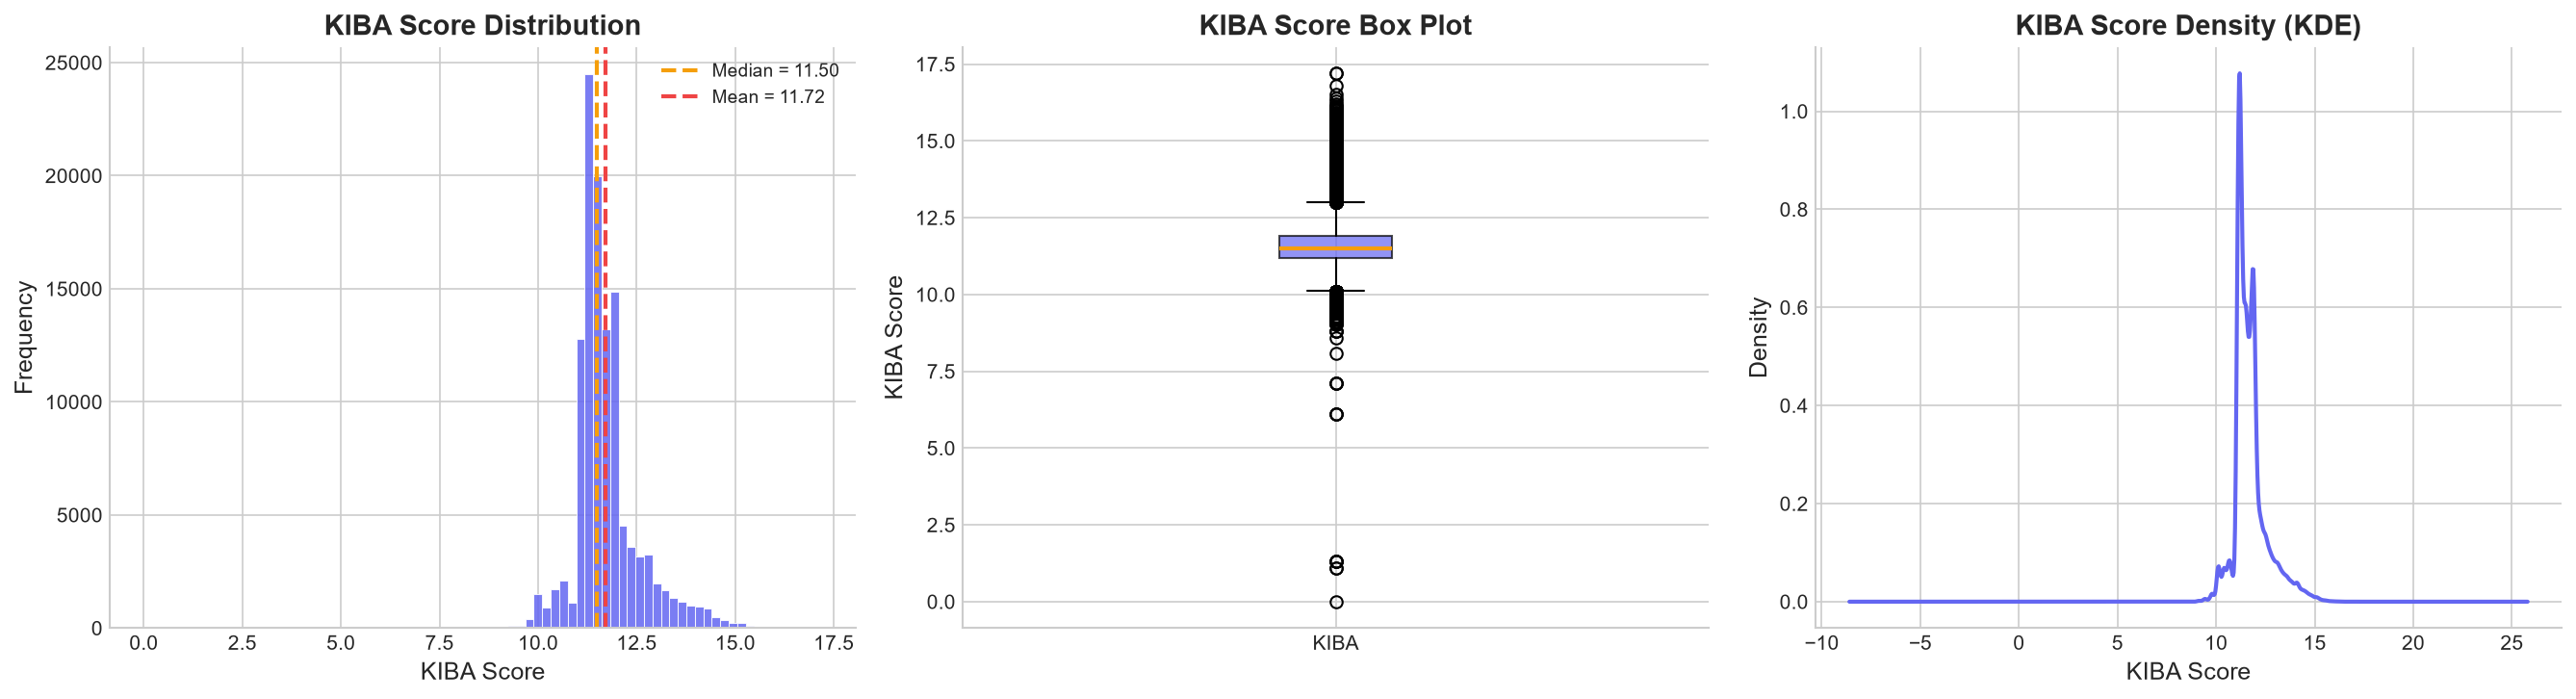

Plot saved: C:\Users\ASUS\Documents\projects\Pharmalens\results\figures\score_distribution.png


In [14]:
# Score distribution plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histogram
axes[0].hist(df['score'], bins=80, color=COLORS['primary'], alpha=0.85, edgecolor='white', linewidth=0.5)
axes[0].axvline(df['score'].median(), color=COLORS['warning'], linestyle='--', linewidth=2, label=f"Median = {df['score'].median():.2f}")
axes[0].axvline(df['score'].mean(), color=COLORS['error'], linestyle='--', linewidth=2, label=f"Mean = {df['score'].mean():.2f}")
axes[0].set_xlabel('KIBA Score')
axes[0].set_ylabel('Frequency')
axes[0].set_title('KIBA Score Distribution', fontweight='bold')
axes[0].legend(fontsize=9)

# Box plot
bp = axes[1].boxplot(df['score'], vert=True, patch_artist=True,
                      boxprops=dict(facecolor=COLORS['primary'], alpha=0.7),
                      medianprops=dict(color=COLORS['warning'], linewidth=2))
axes[1].set_ylabel('KIBA Score')
axes[1].set_title('KIBA Score Box Plot', fontweight='bold')
axes[1].set_xticklabels(['KIBA'])

# KDE plot
df['score'].plot.kde(ax=axes[2], color=COLORS['primary'], linewidth=2)
axes[2].fill_between([], [], alpha=0.3)  # placeholder for fill
axes[2].set_xlabel('KIBA Score')
axes[2].set_ylabel('Density')
axes[2].set_title('KIBA Score Density (KDE)', fontweight='bold')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'score_distribution.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"Plot saved: {FIGURES_DIR / 'score_distribution.png'}")

## 8. Drug Distribution

How are interactions distributed across drugs? Are some drugs tested against many targets while others are tested against very few?

Drug interaction counts:
  Mean interactions per drug: 56.0
  Median: 30
  Min: 11
  Max: 166
  Std: 48.6


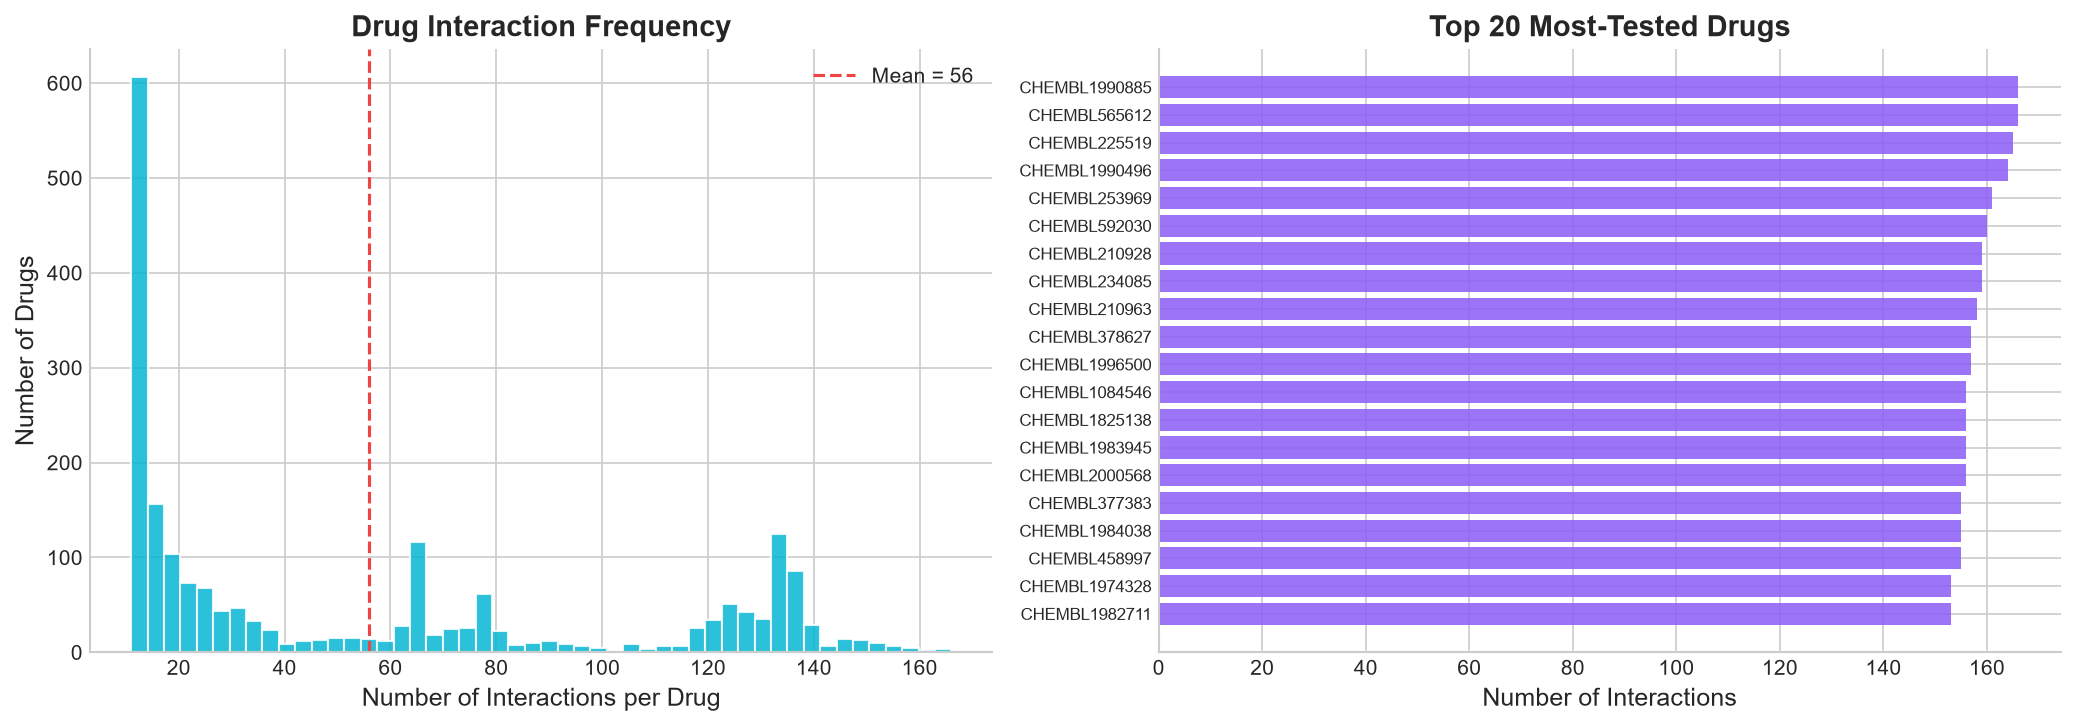

Plot saved: C:\Users\ASUS\Documents\projects\Pharmalens\results\figures\drug_distribution.png


In [15]:
# Drug frequency distribution
drug_counts = df['drug_id'].value_counts()

print(f"Drug interaction counts:")
print(f"  Mean interactions per drug: {drug_counts.mean():.1f}")
print(f"  Median: {drug_counts.median():.0f}")
print(f"  Min: {drug_counts.min()}")
print(f"  Max: {drug_counts.max()}")
print(f"  Std: {drug_counts.std():.1f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of interactions per drug
axes[0].hist(drug_counts, bins=50, color=COLORS['accent'], alpha=0.85, edgecolor='white')
axes[0].set_xlabel('Number of Interactions per Drug')
axes[0].set_ylabel('Number of Drugs')
axes[0].set_title('Drug Interaction Frequency', fontweight='bold')
axes[0].axvline(drug_counts.mean(), color=COLORS['error'], linestyle='--', label=f'Mean = {drug_counts.mean():.0f}')
axes[0].legend()

# Top 20 most-tested drugs
top_drugs = drug_counts.head(20)
axes[1].barh(range(len(top_drugs)), top_drugs.values, color=COLORS['secondary'], alpha=0.85)
axes[1].set_yticks(range(len(top_drugs)))
axes[1].set_yticklabels([str(x)[:15] for x in top_drugs.index], fontsize=8)
axes[1].set_xlabel('Number of Interactions')
axes[1].set_title('Top 20 Most-Tested Drugs', fontweight='bold')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'drug_distribution.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"Plot saved: {FIGURES_DIR / 'drug_distribution.png'}")

## 9. Protein Target Distribution

How are interactions distributed across protein targets?

Target interaction counts:
  Mean interactions per target: 516.4
  Median: 567
  Min: 11
  Max: 1452
  Std: 352.5


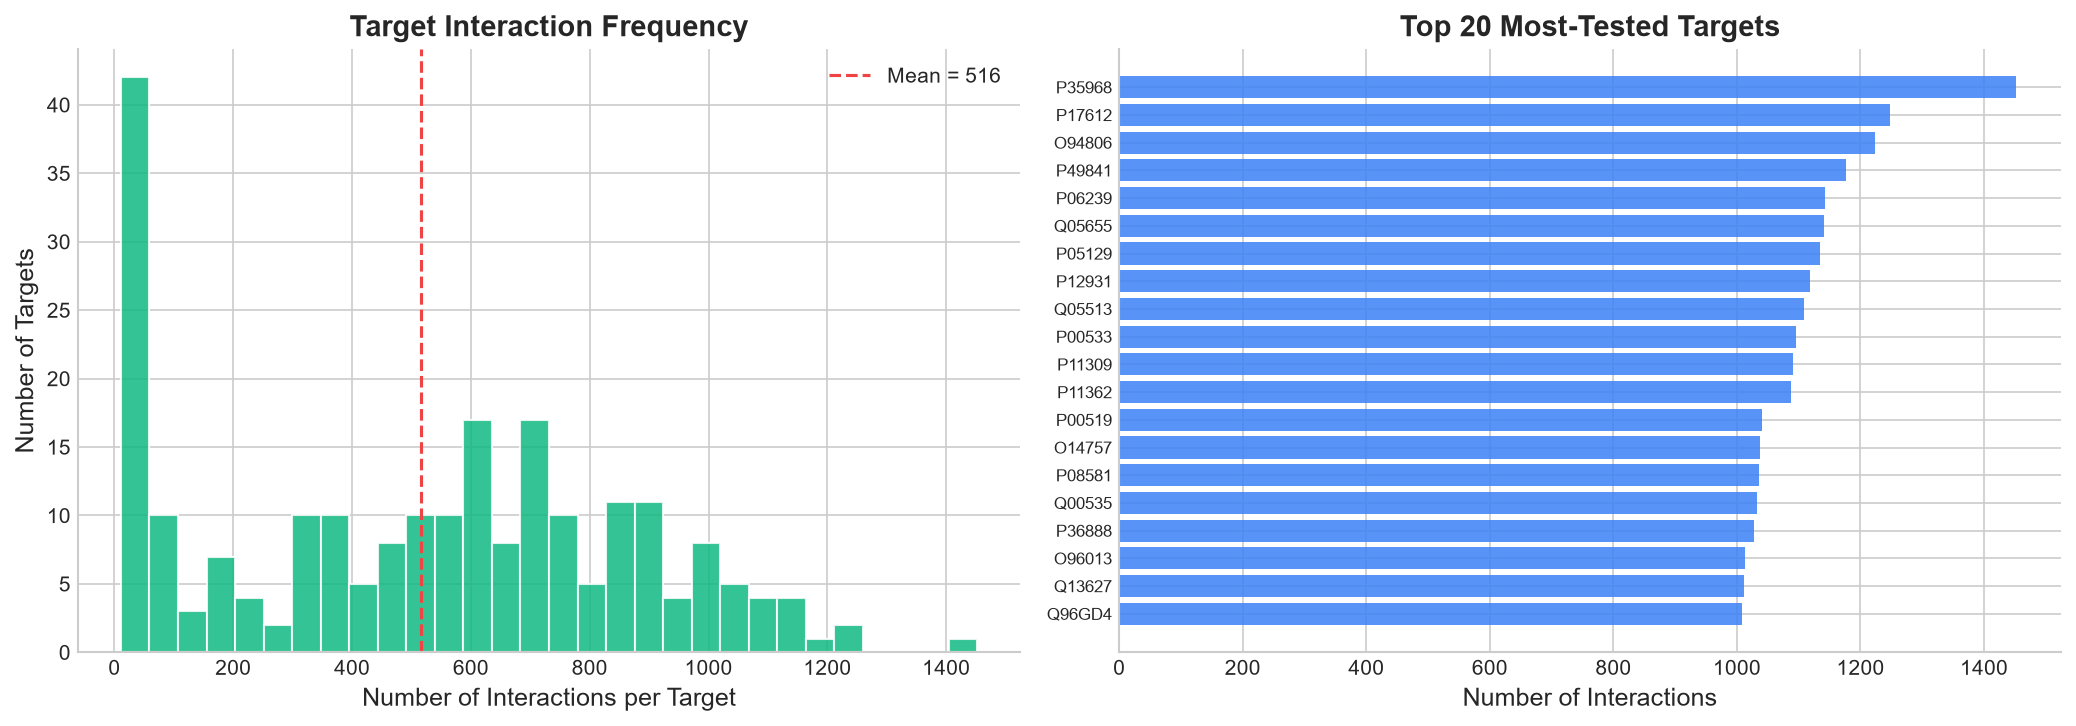

Plot saved: C:\Users\ASUS\Documents\projects\Pharmalens\results\figures\target_distribution.png


In [16]:
# Protein target frequency distribution
target_counts = df['target_id'].value_counts()

print(f"Target interaction counts:")
print(f"  Mean interactions per target: {target_counts.mean():.1f}")
print(f"  Median: {target_counts.median():.0f}")
print(f"  Min: {target_counts.min()}")
print(f"  Max: {target_counts.max()}")
print(f"  Std: {target_counts.std():.1f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of interactions per target
axes[0].hist(target_counts, bins=30, color=COLORS['success'], alpha=0.85, edgecolor='white')
axes[0].set_xlabel('Number of Interactions per Target')
axes[0].set_ylabel('Number of Targets')
axes[0].set_title('Target Interaction Frequency', fontweight='bold')
axes[0].axvline(target_counts.mean(), color=COLORS['error'], linestyle='--', label=f'Mean = {target_counts.mean():.0f}')
axes[0].legend()

# Top 20 most-tested targets
top_targets = target_counts.head(20)
axes[1].barh(range(len(top_targets)), top_targets.values, color=COLORS['info'], alpha=0.85)
axes[1].set_yticks(range(len(top_targets)))
axes[1].set_yticklabels([str(x)[:20] for x in top_targets.index], fontsize=8)
axes[1].set_xlabel('Number of Interactions')
axes[1].set_title('Top 20 Most-Tested Targets', fontweight='bold')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'target_distribution.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"Plot saved: {FIGURES_DIR / 'target_distribution.png'}")

## 10. SMILES and Sequence Length Analysis

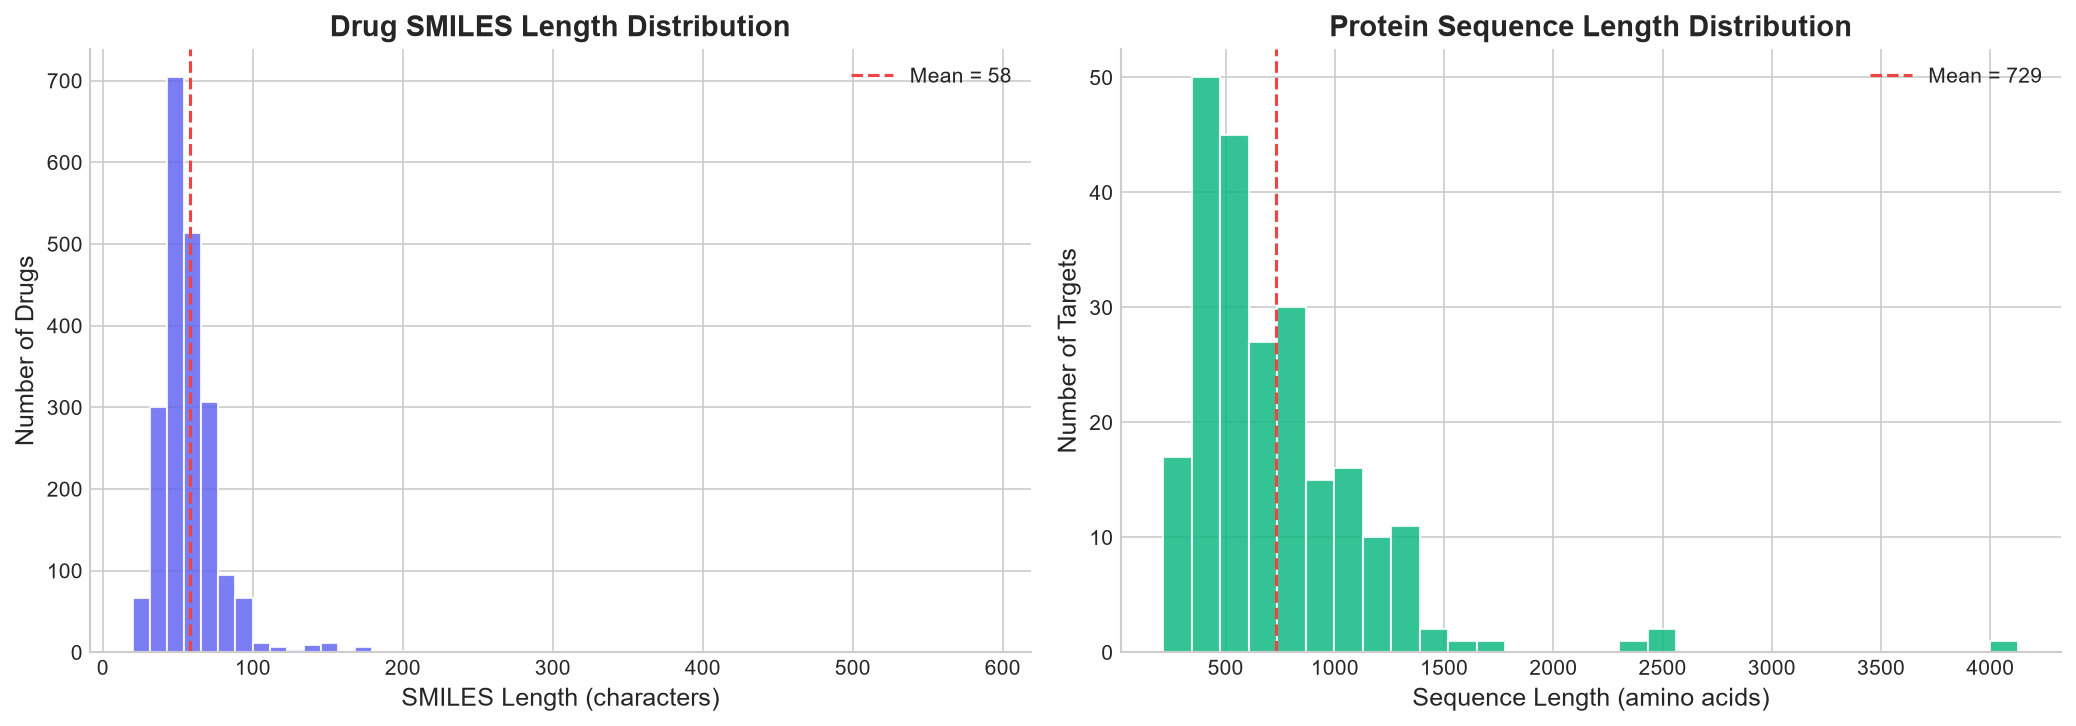

SMILES length — Mean: 58, Min: 20, Max: 590
Sequence length — Mean: 729, Min: 215, Max: 4128


In [17]:
# SMILES length distribution
df['smiles_length'] = df['smiles'].str.len()
df['sequence_length'] = df['sequence'].str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# SMILES length
unique_smiles_lengths = df.drop_duplicates('drug_id')['smiles_length']
axes[0].hist(unique_smiles_lengths, bins=50, color=COLORS['primary'], alpha=0.85, edgecolor='white')
axes[0].set_xlabel('SMILES Length (characters)')
axes[0].set_ylabel('Number of Drugs')
axes[0].set_title('Drug SMILES Length Distribution', fontweight='bold')
axes[0].axvline(unique_smiles_lengths.mean(), color=COLORS['error'], linestyle='--',
                label=f'Mean = {unique_smiles_lengths.mean():.0f}')
axes[0].legend()

# Sequence length
unique_seq_lengths = df.drop_duplicates('target_id')['sequence_length']
axes[1].hist(unique_seq_lengths, bins=30, color=COLORS['success'], alpha=0.85, edgecolor='white')
axes[1].set_xlabel('Sequence Length (amino acids)')
axes[1].set_ylabel('Number of Targets')
axes[1].set_title('Protein Sequence Length Distribution', fontweight='bold')
axes[1].axvline(unique_seq_lengths.mean(), color=COLORS['error'], linestyle='--',
                label=f'Mean = {unique_seq_lengths.mean():.0f}')
axes[1].legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'length_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"SMILES length — Mean: {unique_smiles_lengths.mean():.0f}, Min: {unique_smiles_lengths.min()}, Max: {unique_smiles_lengths.max()}")
print(f"Sequence length — Mean: {unique_seq_lengths.mean():.0f}, Min: {unique_seq_lengths.min()}, Max: {unique_seq_lengths.max()}")

## 11. Interaction Matrix Visualization

The interaction matrix shows which drug–target combinations have been measured. Due to the large size of the full matrix, we visualize a sampled subset.

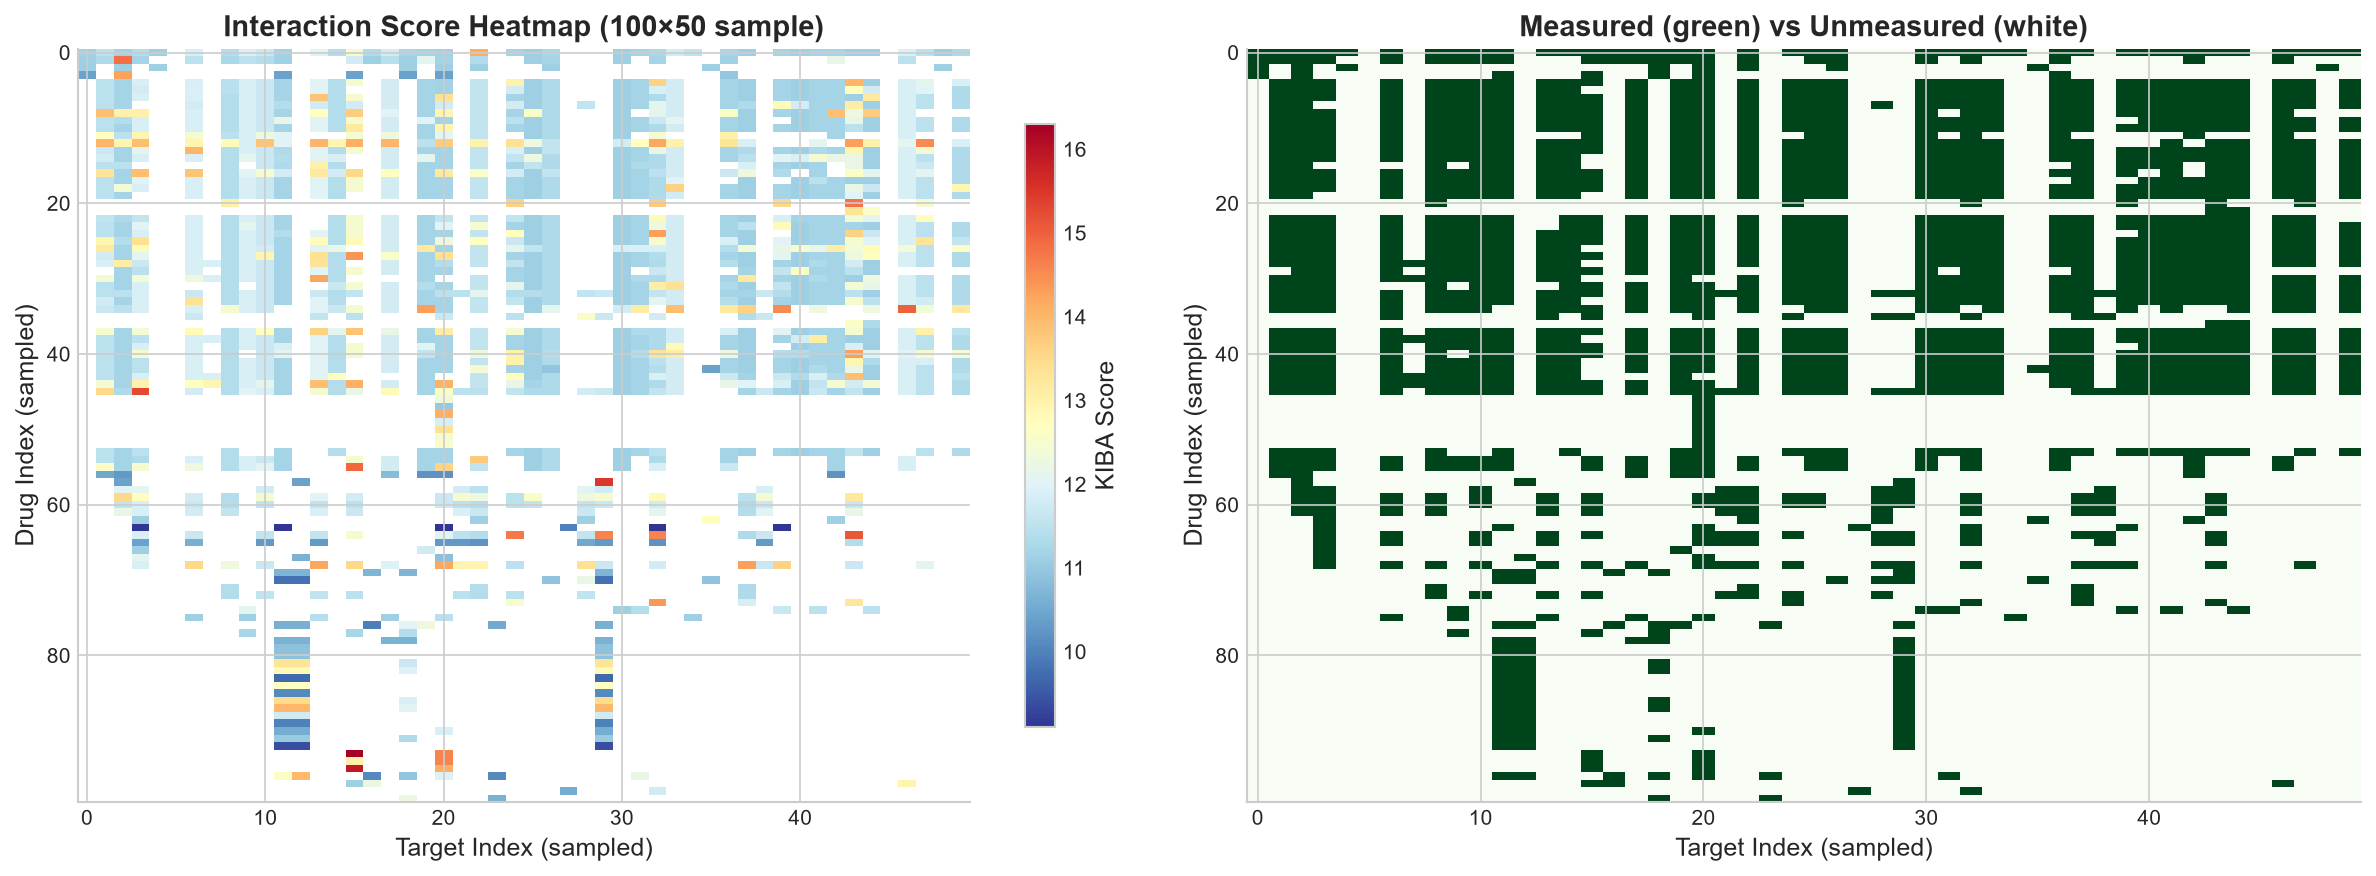

Plot saved: C:\Users\ASUS\Documents\projects\Pharmalens\results\figures\interaction_matrix.png


In [18]:
# Interaction matrix heatmap (sampled)
# Sample a subset for visualization
np.random.seed(42)
n_sample_drugs = min(100, Y.shape[0])
n_sample_targets = min(50, Y.shape[1])

drug_idx = np.random.choice(Y.shape[0], n_sample_drugs, replace=False)
target_idx = np.random.choice(Y.shape[1], n_sample_targets, replace=False)
Y_sample = Y[np.ix_(sorted(drug_idx), sorted(target_idx))]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Heatmap of scores (NaN as grey)
im1 = axes[0].imshow(Y_sample, aspect='auto', cmap='RdYlBu_r', interpolation='nearest')
axes[0].set_xlabel('Target Index (sampled)')
axes[0].set_ylabel('Drug Index (sampled)')
axes[0].set_title(f'Interaction Score Heatmap ({n_sample_drugs}×{n_sample_targets} sample)', fontweight='bold')
plt.colorbar(im1, ax=axes[0], label='KIBA Score', shrink=0.8)

# Binary: measured vs unmeasured
measured_mask = (~np.isnan(Y_sample)).astype(float)
im2 = axes[1].imshow(measured_mask, aspect='auto', cmap='Greens', interpolation='nearest')
axes[1].set_xlabel('Target Index (sampled)')
axes[1].set_ylabel('Drug Index (sampled)')
axes[1].set_title('Measured (green) vs Unmeasured (white)', fontweight='bold')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'interaction_matrix.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"Plot saved: {FIGURES_DIR / 'interaction_matrix.png'}")

## 12. Score Distribution by Quartile

Score Quartiles:
  Q1 (25th percentile): 11.2000
  Q2 (50th percentile / median): 11.5000
  Q3 (75th percentile): 11.9239
  IQR: 0.7239


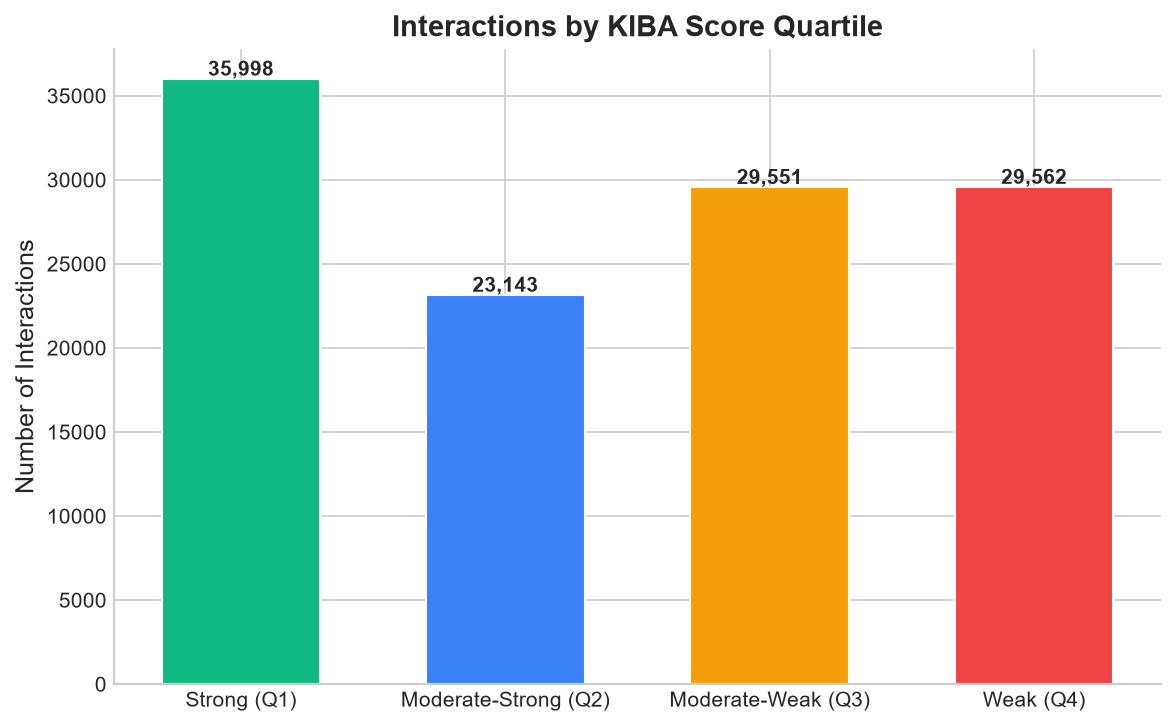

In [19]:
# Quartile analysis — helps understand potential thresholds for classification
q25, q50, q75 = df['score'].quantile([0.25, 0.50, 0.75])

print(f"Score Quartiles:")
print(f"  Q1 (25th percentile): {q25:.4f}")
print(f"  Q2 (50th percentile / median): {q50:.4f}")
print(f"  Q3 (75th percentile): {q75:.4f}")
print(f"  IQR: {q75 - q25:.4f}")

# Distribution of interactions in score ranges
bins = [df['score'].min(), q25, q50, q75, df['score'].max()]
labels = ['Strong (Q1)', 'Moderate-Strong (Q2)', 'Moderate-Weak (Q3)', 'Weak (Q4)']
df['score_quartile'] = pd.cut(df['score'], bins=bins, labels=labels, include_lowest=True)

quartile_counts = df['score_quartile'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 5))
colors_q = [COLORS['success'], COLORS['info'], COLORS['warning'], COLORS['error']]
bars = ax.bar(quartile_counts.index.astype(str), quartile_counts.values, color=colors_q, edgecolor='white', width=0.6)

for bar, val in zip(bars, quartile_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f'{val:,}', ha='center', fontsize=10, fontweight='bold')

ax.set_ylabel('Number of Interactions')
ax.set_title('Interactions by KIBA Score Quartile', fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'score_quartiles.png', dpi=300, bbox_inches='tight')
plt.show()

# Cleanup
df = df.drop(columns=['score_quartile', 'smiles_length', 'sequence_length'])

## 13. Generate and Save Dataset Summary

In [20]:
# Generate comprehensive summary
summary = generate_dataset_summary(df, Y, "kiba")

# Print the summary
print_dataset_summary(summary)

2026-09-11 21:37:02 | pharmalens.data | INFO | Dataset summary saved to C:\Users\ASUS\Documents\projects\Pharmalens\data\metadata\kiba_summary.json


  DATASET SUMMARY: KIBA
  Matrix shape:           [2111, 229]
  Total entries:          483,419
  Measured interactions:  118,254
  Unmeasured (NaN):       365,165
  Sparsity:               75.54%
  ─────────────────────────────────────────────────
  DataFrame records:      118,254
  Unique drugs:           2111
  Unique targets:         229
  Duplicate pairs:        0
  ─────────────────────────────────────────────────
  Score mean ± std:       11.7199 ± 0.8369
  Score range:            [0.0000, 17.2002]
  Score median:           11.5000
  Score Q25/Q75:          11.2000 / 11.9239
  ─────────────────────────────────────────────────
  SMILES length:          20–590 (avg 54.6)
  Sequence length:        215–4128 (avg 730.9)


In [21]:
# Also save the DataFrame for the next notebook
output_path = PROCESSED_DATA_DIR / "kiba_raw_interactions.csv"
df.to_csv(output_path, index=False)
print(f"\nRaw interaction DataFrame saved: {output_path}")
print(f"File size: {output_path.stat().st_size / 1024 / 1024:.1f} MB")


Raw interaction DataFrame saved: C:\Users\ASUS\Documents\projects\Pharmalens\data\processed\kiba_raw_interactions.csv
File size: 92.7 MB


## Observations

Based on the exploration above, key observations about the KIBA dataset:

1. **Scale:** The dataset contains a substantial number of measured drug–target interactions, providing sufficient data for training machine learning models.

2. **Sparsity:** The interaction matrix is sparse — most drug–target combinations have NOT been experimentally measured. This is typical of DTI datasets because exhaustive testing is impractical.

3. **Score Distribution:** The KIBA scores show a characteristic distribution. The median and mean give us reference points for understanding the typical interaction strength in this dataset.

4. **Drug/Target Coverage:** Some drugs and targets are tested more extensively than others. This uneven coverage is important to consider during model training and evaluation.

5. **Sequence Lengths:** Drug SMILES and protein sequences vary in length, which will affect how we encode them for different model architectures (e.g., fixed-length padding for CNN models).

6. **Data Quality:** We will need to validate SMILES strings and protein sequences in the next notebook to ensure all inputs are chemically/biologically valid.

## Conclusion

This notebook has established a comprehensive understanding of the KIBA dataset:

- The dataset has been downloaded, loaded, and converted into a usable DataFrame format
- All key statistics have been computed and saved to `data/metadata/kiba_summary.json`
- Visualizations have been generated and saved to `results/figures/`
- The raw interaction DataFrame has been saved for the next processing step

**Next:** [Notebook 02 — Data Preprocessing](./02_data_preprocessing.ipynb) will validate drug SMILES, protein sequences, handle duplicates, and produce a clean dataset ready for feature extraction.